In [1]:
# =====================================================
# PROJETO 05 - SISTEMAS INTELIGENTES
# MLP PARA DETECÇÃO DE INTRUSÃO - NSL-KDD
# =====================================================

# =====================================================
# IMPORTAÇÕES
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import kagglehub

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [2]:

# =====================================================
# DOWNLOAD DO DATASET VIA KAGGLEHUB
# =====================================================

path = kagglehub.dataset_download("hassan06/nslkdd")

print("Path to dataset files:", path)

# =====================================================
# CAMINHOS DOS ARQUIVOS
# =====================================================

train_path = os.path.join(path, "KDDTrain+.txt")
test_path = os.path.join(path, "KDDTest+.txt")

# =====================================================
# COLUNAS DO DATASET
# =====================================================

col_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "attack_type", "difficulty_level"
]

# =====================================================
# CARREGAMENTO DOS DADOS
# =====================================================

train_df = pd.read_csv(
    train_path,
    names=col_names
)

test_df = pd.read_csv(
    test_path,
    names=col_names
)

print("Treino:", train_df.shape)
print("Teste:", test_df.shape)

# =====================================================
# REMOÇÃO DA COLUNA difficulty_level
# =====================================================

train_df.drop("difficulty_level", axis=1, inplace=True)
test_df.drop("difficulty_level", axis=1, inplace=True)



Using Colab cache for faster access to the 'nslkdd' dataset.
Path to dataset files: /kaggle/input/nslkdd
Treino: (125973, 43)
Teste: (22544, 43)


In [3]:
# =====================================================
# BINARIZAÇÃO DOS RÓTULOS
# normal -> 0
# ataque -> 1
# =====================================================

train_df["attack_type"] = train_df["attack_type"].apply(
    lambda x: 0 if x == "normal" else 1
)

test_df["attack_type"] = test_df["attack_type"].apply(
    lambda x: 0 if x == "normal" else 1
)



In [4]:
# =====================================================
# ONE-HOT ENCODING
# =====================================================

categorical_cols = ["protocol_type", "service", "flag"]

train_df = pd.get_dummies(
    train_df,
    columns=categorical_cols
)

test_df = pd.get_dummies(
    test_df,
    columns=categorical_cols
)



In [5]:
# =====================================================
# ALINHANDO COLUNAS ENTRE TREINO E TESTE
# =====================================================

train_df, test_df = train_df.align(
    test_df,
    join="left",
    axis=1,
    fill_value=0
)

# =====================================================
# DIVISÃO ENTRE FEATURES E RÓTULOS
# =====================================================

X = train_df.drop("attack_type", axis=1)
y = train_df["attack_type"]

X_test = test_df.drop("attack_type", axis=1)
y_test = test_df["attack_type"]

# =====================================================
# DIVISÃO TREINO E VALIDAÇÃO
# 80% treino
# 20% validação
# =====================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

# =====================================================
# NORMALIZAÇÃO Z-SCORE
# Ajuste SOMENTE no treino
# =====================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

# =====================================================
# CONVERSÃO PARA TENSORES
# =====================================================

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(
    y_train.values,
    dtype=torch.float32
).view(-1, 1)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(
    y_val.values,
    dtype=torch.float32
).view(-1, 1)

X_test = torch.tensor(X_test, dtype=torch.float32)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
).view(-1, 1)



In [6]:
# =====================================================
# DATASETS E DATALOADERS
# =====================================================

train_dataset = TensorDataset(X_train, y_train)

val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False
)


Época 1/50 | Train Loss: 0.0893 | Val Loss: 0.0353
Época 2/50 | Train Loss: 0.0294 | Val Loss: 0.0261
Época 3/50 | Train Loss: 0.0214 | Val Loss: 0.0200
Época 4/50 | Train Loss: 0.0192 | Val Loss: 0.0180
Época 5/50 | Train Loss: 0.0174 | Val Loss: 0.0178
Época 6/50 | Train Loss: 0.0161 | Val Loss: 0.0165
Época 7/50 | Train Loss: 0.0153 | Val Loss: 0.0151
Época 8/50 | Train Loss: 0.0143 | Val Loss: 0.0177
Época 9/50 | Train Loss: 0.0133 | Val Loss: 0.0141
Época 10/50 | Train Loss: 0.0125 | Val Loss: 0.0136
Época 11/50 | Train Loss: 0.0120 | Val Loss: 0.0169
Época 12/50 | Train Loss: 0.0119 | Val Loss: 0.0133
Época 13/50 | Train Loss: 0.0115 | Val Loss: 0.0143
Época 14/50 | Train Loss: 0.0110 | Val Loss: 0.0145
Época 15/50 | Train Loss: 0.0106 | Val Loss: 0.0154
Época 16/50 | Train Loss: 0.0100 | Val Loss: 0.0153
Época 17/50 | Train Loss: 0.0101 | Val Loss: 0.0171

Early Stopping ativado!


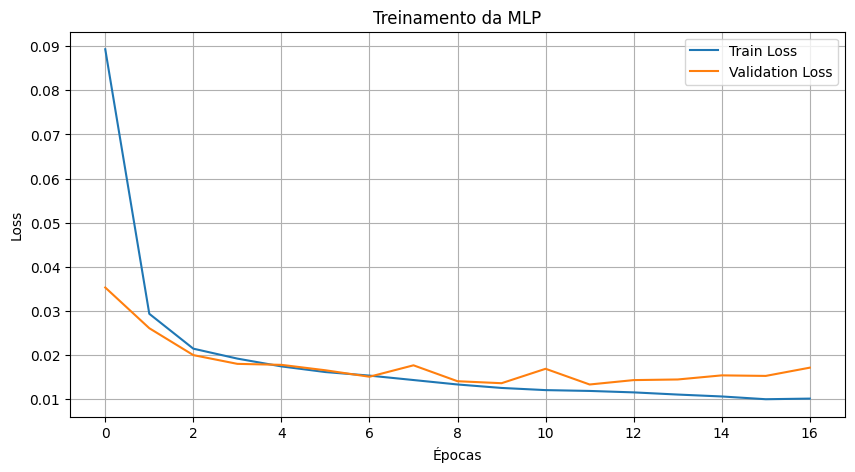

In [7]:

# =====================================================
# DEFINIÇÃO DA REDE MLP
# =====================================================

class MLP(nn.Module):

    def __init__(self, input_size):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)

        )

    def forward(self, x):

        return self.network(x)

# =====================================================
# INSTÂNCIA DO MODELO
# =====================================================

input_size = X_train.shape[1]

model = MLP(input_size)

# =====================================================
# FUNÇÃO DE PERDA E OTIMIZADOR
# =====================================================

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# =====================================================
# TREINAMENTO
# =====================================================

num_epochs = 50

train_losses = []
val_losses = []

# =====================================================
# EARLY STOPPING
# =====================================================

best_val_loss = np.inf

patience = 5

counter = 0

for epoch in range(num_epochs):

    # =================================================
    # TREINO
    # =================================================

    model.train()

    running_train_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(train_loader)

    train_losses.append(epoch_train_loss)

    # =================================================
    # VALIDAÇÃO
    # =================================================

    model.eval()

    running_val_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(val_loader)

    val_losses.append(epoch_val_loss)

    print(
        f"Época {epoch+1}/{num_epochs} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f}"
    )

    # =================================================
    # EARLY STOPPING
    # =================================================

    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss

        counter = 0

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )

    else:

        counter += 1

        if counter >= patience:

            print("\nEarly Stopping ativado!")

            break

# =====================================================
# CARREGANDO MELHOR MODELO
# =====================================================

model.load_state_dict(
    torch.load("best_model.pth")
)

# =====================================================
# CURVAS DE LOSS
# =====================================================

plt.figure(figsize=(10, 5))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Épocas")

plt.ylabel("Loss")

plt.title("Treinamento da MLP")

plt.legend()

plt.grid(True)

plt.show()



In [8]:
# =====================================================
# AVALIAÇÃO FINAL
# =====================================================

model.eval()

with torch.no_grad():

    logits = model(X_test)

    probs = torch.sigmoid(logits)

    preds = (probs >= 0.5).int()

# =====================================================
# CONVERSÃO PARA NUMPY
# =====================================================

y_pred = preds.cpu().numpy()

# =====================================================
# MÉTRICAS
# =====================================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

# =====================================================
# RESULTADOS
# =====================================================

print("\n========== RESULTADOS ==========")

print(f"Acurácia : {accuracy:.4f}")

print(f"Precisão : {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1-score : {f1:.4f}")

# =====================================================
# MATRIZ DE CONFUSÃO
# =====================================================

cm = confusion_matrix(y_test, y_pred)

print("\n========== MATRIZ DE CONFUSÃO ==========")

print(cm)

# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        y_pred
    )
)


========== RESULTADOS ==========
Acurácia : 0.7966
Precisão : 0.9279
Recall   : 0.6969
F1-score : 0.7960

========== MATRIZ DE CONFUSÃO ==========
[[9016  695]
 [3890 8943]]

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0       0.70      0.93      0.80      9711
           1       0.93      0.70      0.80     12833

    accuracy                           0.80     22544
   macro avg       0.81      0.81      0.80     22544
weighted avg       0.83      0.80      0.80     22544

